In [2]:
import psycopg2
import sys

#Define our connection string
conn_string = "host='localhost' port=5432 dbname='piscineds' user='jhervoch' password='mysecretpassword'"

# print the connection string we will use to connect
print (f"Connecting to database\n	->{conn_string}")

# get a connection, if a connect cannot be made an exception will be raised here
conn = psycopg2.connect(conn_string)

# conn.cursor will return a cursor object, you can use this cursor to perform queries
cursor = conn.cursor()
print ("Connected!\n")

cursor.execute("SELECT version();")
print(cursor.fetchone())


Connecting to database
	->host='localhost' port=5432 dbname='piscineds' user='jhervoch' password='mysecretpassword'
Connected!

('PostgreSQL 18.4 (Debian 18.4-1.pgdg13+1) on aarch64-unknown-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit',)


In [9]:
cursor.execute("SELECT event_time, event_type, product_id, price, user_id, user_session FROM customers LIMIT 50;")

In [10]:
data = cursor.fetchall()
print(data)

[(datetime.datetime(2023, 1, 13, 21, 19, 1, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549565923, '78e75242-dc51-4b84-a276-2ae0958364fa'), (datetime.datetime(2023, 1, 30, 10, 27, 39, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549577835, '5be786ab-fccd-4e3a-ba2b-6bf7f254878a'), (datetime.datetime(2023, 1, 31, 12, 13, 47, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549577835, '5be786ab-fccd-4e3a-ba2b-6bf7f254878a'), (datetime.datetime(2023, 1, 5, 5, 32, 55, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549586456, '60b475bb-e058-480a-bb48-288f3c0a8e0a'), (datetime.datetime(2023, 1, 5, 5, 35, 42, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549586456, '60b475bb-e058-480a-bb48-288f3c0a8e0a'), (datetime.datetime(2023, 1, 22, 12, 6, 17, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549688462, 'e6db9d7a-277c-4b1c-8032-8316d06044b9'), (datetime.datetime(2023, 1, 29, 1

In [5]:
row_count = 0
for row in cursor:
    row_count += 1
    print (f"row: {row_count}    {row}\n")

row: 1    (datetime.datetime(2023, 1, 13, 21, 19, 1, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549565923, '78e75242-dc51-4b84-a276-2ae0958364fa')

row: 2    (datetime.datetime(2023, 1, 30, 10, 27, 39, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549577835, '5be786ab-fccd-4e3a-ba2b-6bf7f254878a')

row: 3    (datetime.datetime(2023, 1, 31, 12, 13, 47, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549577835, '5be786ab-fccd-4e3a-ba2b-6bf7f254878a')

row: 4    (datetime.datetime(2023, 1, 5, 5, 32, 55, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549586456, '60b475bb-e058-480a-bb48-288f3c0a8e0a')

row: 5    (datetime.datetime(2023, 1, 5, 5, 35, 42, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549586456, '60b475bb-e058-480a-bb48-288f3c0a8e0a')

row: 6    (datetime.datetime(2023, 1, 22, 12, 6, 17, tzinfo=datetime.timezone.utc), 'view', 5917178, Decimal('16.35'), 549688462, 'e6db9d7a-277c-

In [23]:
import pandas as df
column_names = ['event_time','event_type', 'product_id', 'price', 'user_id', 'user_session' ]
df = df.DataFrame(data, columns=column_names)

print(df.head())
df["user_id"].value_counts()

                 event_time event_type  product_id  price    user_id  \
0 2023-01-13 21:19:01+00:00       view     5917178  16.35  549565923   
1 2023-01-30 10:27:39+00:00       view     5917178  16.35  549577835   
2 2023-01-31 12:13:47+00:00       view     5917178  16.35  549577835   
3 2023-01-05 05:32:55+00:00       view     5917178  16.35  549586456   
4 2023-01-05 05:35:42+00:00       view     5917178  16.35  549586456   

                           user_session  
0  78e75242-dc51-4b84-a276-2ae0958364fa  
1  5be786ab-fccd-4e3a-ba2b-6bf7f254878a  
2  5be786ab-fccd-4e3a-ba2b-6bf7f254878a  
3  60b475bb-e058-480a-bb48-288f3c0a8e0a  
4  60b475bb-e058-480a-bb48-288f3c0a8e0a  


user_id
550328876    13
550237325     4
549919715     3
550134824     3
550236316     3
549577835     2
549586456     2
549760568     2
550131148     2
549565923     1
549688462     1
549693328     1
549799296     1
549807988     1
549903361     1
549916472     1
550009004     1
550050993     1
550070175     1
550131261     1
550169573     1
550185092     1
550209066     1
550246263     1
550264880     1
Name: count, dtype: int64

                 event_time event_type  product_id  price    user_id  \
0 2023-01-13 21:19:01+00:00       view     5917178  16.35  549565923   
1 2023-01-30 10:27:39+00:00       view     5917178  16.35  549577835   
2 2023-01-31 12:13:47+00:00       view     5917178  16.35  549577835   
3 2023-01-05 05:32:55+00:00       view     5917178  16.35  549586456   
4 2023-01-05 05:35:42+00:00       view     5917178  16.35  549586456   

                           user_session  
0  78e75242-dc51-4b84-a276-2ae0958364fa  
1  5be786ab-fccd-4e3a-ba2b-6bf7f254878a  
2  5be786ab-fccd-4e3a-ba2b-6bf7f254878a  
3  60b475bb-e058-480a-bb48-288f3c0a8e0a  
4  60b475bb-e058-480a-bb48-288f3c0a8e0a  


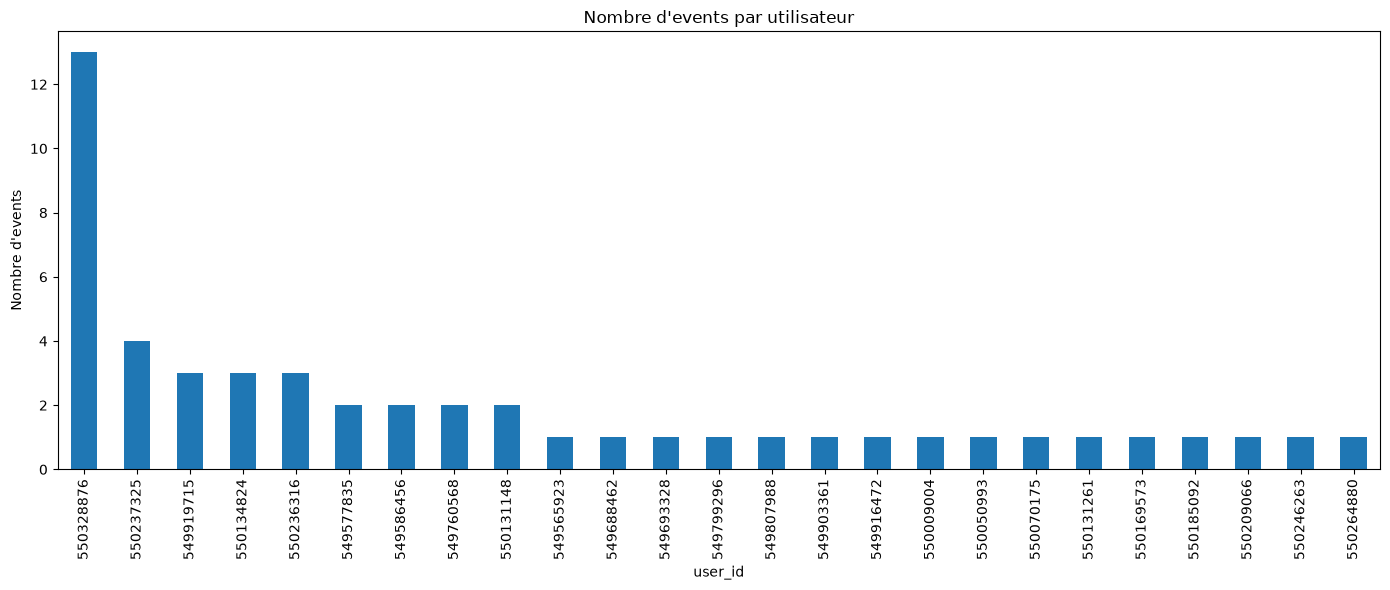

In [26]:
import pandas as df
import matplotlib.pyplot as plt
column_names = ['event_time','event_type', 'product_id', 'price', 'user_id', 'user_session' ]
df = df.DataFrame(data, columns=column_names)

print(df.head())
counts = df["user_id"].value_counts()

plt.figure(figsize=(14, 6))
counts.plot(kind="bar")

plt.xlabel("user_id")
plt.ylabel("Nombre d'events")
plt.title("Nombre d'events par utilisateur")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()